# CRE 3 - Assignment 3 : PFTR Model for Ethylene Oxide Hydrolysis

Group 6: 

 Ivanna Garzon 3104602

 Franziska Jehle 1136767
 
 Saif...

Reaction Conditions:
    
Onuorah, Gunorubon: Continuous  Stirred  Tank Reactor for the Non-Catalytic hydrolysis of Ethylene Oxide to Mono Ethylene Glycol (MEG)
                    T = 200 °C, p = 14-22 atm

Design and Analysis: L_R/D_R = 2, 467, 461, 455 kPa, 150 °C
https://doi.org/10.1016/j.cep.2019.107744

DOI 10.31031/PPS.2024.06.000637: 212 °C, 35 bar


assumptions: no backmixing, no side reactions, no consecutive reactions

Process Intensification: reactive distillation

## 1. Introduction and Motivation

....

## PFTR Model

### 2.1 Balance Equations

In the following an ideal plug flow tubular reactor (PFTR) is assumed with steady state behavior. This means there is no backmixing in axial direction and there is ideal mixing in radial direction. This results in no gradients in radial flow direction but gradients in axial flow direction due to chemical reaction. Thus all fluid elements leaving the reactor have the same residence time.

The mass balance for the PFTR can be in general written as:

\begin{align*}
    \frac{dc_i}{d\tau}=\sum_{j}\nu_{i,j}r_j
\end{align*}

$c_i$ is the concentration of component, j the reaction, $\nu_{i,j}$ the stoichiometric factor of component i in reaction j.

This results in the following mass balance equations for the considered reaction:

\begin{align*}
    \frac{dc_{EO}}{d\tau}=-r
\end{align*}

\begin{align*}
    \frac{dc_{H_2O}}{d\tau}=-r
\end{align*}

\begin{align*}
    \frac{dc_{G}}{d\tau}=r
\end{align*}

When we assume a constant fluid velocity $u$, the residence time $\tau$ can also be expressed with the following equation:

\begin{align*}
    d\tau = \frac{dz}{u}
\end{align*}

This and rearranging the equations leads to following expressions for the reaction rate:

\begin{align*}
    r=-u\frac{dc_{EO}}{dz}
\end{align*}

\begin{align*}
    r=-u\frac{dc_{H_2O}}{dz}
\end{align*}

\begin{align*}
    r=u\frac{dc_{EG}}{dz}
\end{align*}

Since a first order reaction kinetics is assumed, the reaction rate can be expressed as follows:

\begin{align*}
    r_{EO}=-\frac{dc_{EO}}{d\tau}=c_{EO} \cdot k(T)=c_{EO} \cdot k_0\cdot \exp\left(-\frac{E_A}{R\,T}\right)
\end{align*}

The heat balance can be written as: 

\begin{align*}
    \rho c_p \frac{dT}{d\tau}=-\sum_{j}r_j\Delta_RH_j-h_W\frac{4}{d_R}(T-\overline{T}_K)
\end{align*}

For a constant fluid velocity through the reactor $u$, the heat balance can also be written as:

\begin{align*}
    \rho c_p u \frac{dT}{dz}=-\sum_{j}r_j\Delta_RH_j-h_W\frac{4}{d_R}(T-\overline{T}_K)
\end{align*}

### 2.2. Import Libraries

In [64]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd

### 2.3 Parameters

In [65]:
# ==========================================
# PARAMETERS
# ==========================================

R = 8.314  # ideal gas constant / J/mol*K

# Kinetics
k0 = 5.01E6 # pre-exponential factor / 1/s
EA = 72500  # #activation energy / J/mol

# Process conditions
u = 1.0      # fluid velocity / m/s
Tin = 423    # inlet temperature / K

# Concentrations
cEO0 = 2.27 * 1000   # inlet concentration of EO / mol/m^3
cEG0 = 0.0           # inlet concentration of EG / mol/m^3

# Thermodynamics
dHr = -92.2e3         # reaction enthalpy / J/mol

rho = 1000           # density / kg/m^3
cp = 4.19e3          # heat capacity / J/kg*K

# Reactor geometry
dR = 0.03            # tube diameter / m
L = 300              # reactor length / m

# Heat transfer
hwall = 0.5e3        # wall heat transfer coefficient / W/m^2*K
Twall = 423          # wall temperature / K

z = np.linspace(0, L, 300)

### 2.4 Geometric relations

In [66]:
A_cross = np.pi * dR**2 / 4
A_wall_per_length = np.pi * dR

### 2.5. Kinetic Model

In [67]:
def kinetics(T, cEO):
    # Arrhenius equation
    k = k0 * np.exp(-EA/(R*T))
    
    # First-order reaction rate
    r = k * cEO
    
    return r

### 2.6. PFTR Model Equations

In [68]:
def PFTR(z, y):
    cEO = y[0]
    cEG = y[1]
    T   = y[2]

    r = kinetics(T, cEO)

    # Species balances
    dcEOdz = -r/u
    dcEGdz = r/u

    # Energy balance
    heat_generation = (-dHr) * r
    heat_transfer = hwall * A_wall_per_length * (T - Twall)

    dTdz = (heat_generation*A_cross - heat_transfer) / (rho*cp*u*A_cross)

    return [dcEOdz, dcEGdz, dTdz]

### 2.7. Initial Conditions

In [69]:
y0 = np.array([cEO0, cEG0, Tin])

### 2.8. Numerical Solution

In [70]:
zeval = np.linspace(0, L, 300)

sol = solve_ivp(
    PFTR,
    [0, L],
    y0,
    method='BDF',
    t_eval=zeval
)

### 2.9. Results

In [71]:
z = sol.t
cEO = sol.y[0]
cEG = sol.y[1]
T = sol.y[2]
X = (cEO0 - cEO) / cEO0

### 2.10. Concentration Profiles

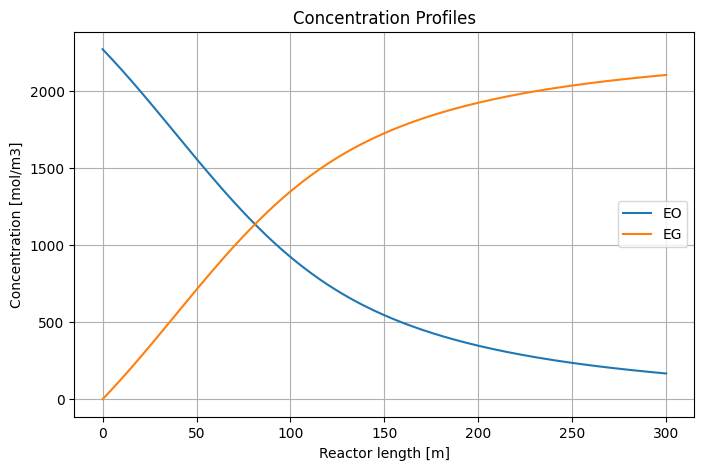

In [72]:
plt.figure(figsize=(8,5))
plt.plot(z, cEO, label='EO')
plt.plot(z, cEG, label='EG')
plt.xlabel('Reactor length [m]')
plt.ylabel('Concentration [mol/m3]')
plt.title('Concentration Profiles')
plt.legend()
plt.grid()
plt.show()

### 2.11. Temperature Profile

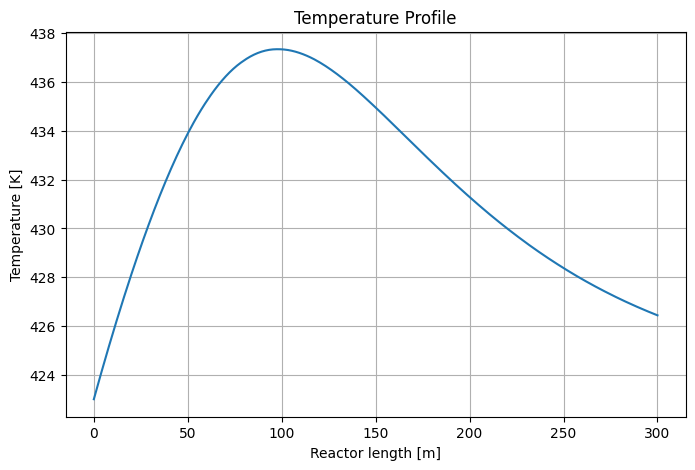

In [73]:
plt.figure(figsize=(8,5))
plt.plot(z, T)
plt.xlabel('Reactor length [m]')
plt.ylabel('Temperature [K]')
plt.title('Temperature Profile')
plt.grid()
plt.show()

### 2.12. Conversion Profile

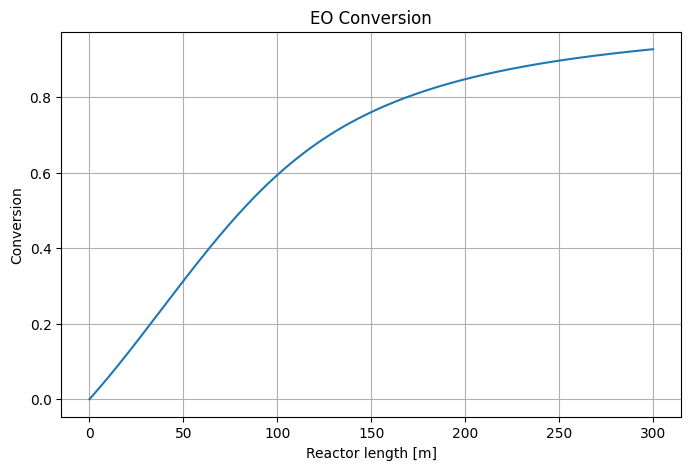

In [74]:
plt.figure(figsize=(8,5))
plt.plot(z, X)
plt.xlabel('Reactor length [m]')
plt.ylabel('Conversion')
plt.title('EO Conversion')
plt.grid()
plt.show()

## 3. Verification Checks

In [75]:
print('Final conversion =', X[-1])
print('Final temperature =', T[-1], 'K')
print('Initial total concentration =', cEO[0] + cEG[0])
print('Final total concentration =', cEO[-1] + cEG[-1])

Final conversion = 0.9264729634624355
Final temperature = 426.4386436483184 K
Initial total concentration = 2270.0
Final total concentration = 2270.000000000001


## 4. Sensitivity Analysis

In [76]:
def reset_base_case():

    global Tin, u, L, dR, hwall
    global A_cross, A_wall_per_length
    global zeval, y0

    Tin = 423
    u = 1.0
    L = 300
    dR = 0.03
    hwall = 0.5e3

    A_cross = np.pi*dR**2/4
    A_wall_per_length = np.pi*dR

    zeval = np.linspace(0, L, 300)

    y0 = np.array([cEO0, cEG0, Tin])

### 4.1. Inlet Temperature

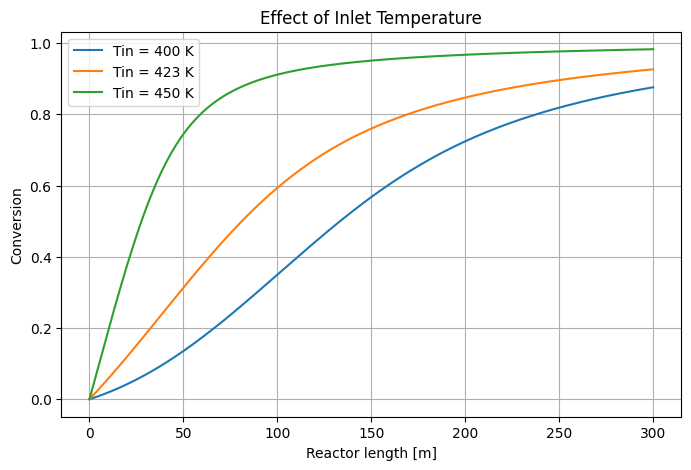

In [77]:
# Reset base case

reset_base_case()

Tin_list = [400, 423, 450]

plt.figure(figsize=(8,5))

for Tin_case in Tin_list:
    y0 = [cEO0, cEG0, Tin_case]
    sol_case = solve_ivp(PFTR,[0,L],y0,method='BDF',t_eval=zeval)
    X_case = (cEO0 - sol_case.y[0]) / cEO0
    plt.plot(sol_case.t, X_case, label=f'Tin = {Tin_case} K')

plt.xlabel('Reactor length [m]')
plt.ylabel('Conversion')
plt.title('Effect of Inlet Temperature')
plt.legend()
plt.grid()
plt.show()

### 4.2. Fluid Velocity

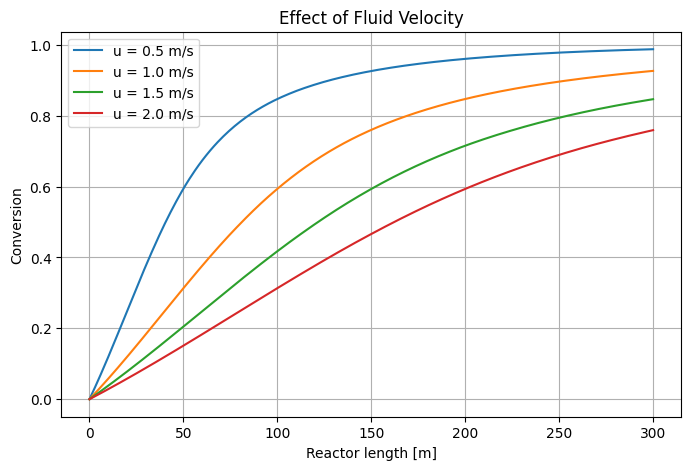

In [78]:
# Reset base case

reset_base_case()

zeval = np.linspace(0, L, 300)

u_list = [0.5, 1.0, 1.5, 2.0]

plt.figure(figsize=(8,5))

for u_case in u_list:

    u = u_case

    y0_case = np.array([cEO0, cEG0, Tin])

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0_case,
        method='BDF',
        t_eval=zeval
    )

    X_case = (cEO0 - sol_case.y[0]) / cEO0

    plt.plot(
        sol_case.t,
        X_case,
        label=f'u = {u_case} m/s'
    )

plt.xlabel('Reactor length [m]')
plt.ylabel('Conversion')
plt.title('Effect of Fluid Velocity')
plt.legend()
plt.grid()
plt.show()

u = 1.0

### 4.3. Reactor Length

In [79]:
# Reset base case

reset_base_case()

L_list = [100, 200, 300, 400, 500]

summary = []

for L_case in L_list:

    zeval_case = np.linspace(0, L_case, 300)

    sol_case = solve_ivp(
        PFTR,
        [0, L_case],
        y0,
        method='BDF',
        t_eval=zeval_case
    )

    X_case = (cEO0 - sol_case.y[0]) / cEO0

    summary.append({
        "Reactor Length (m)": L_case,
        "Outlet Conversion (%)": 100 * X_case[-1]
    })

df = pd.DataFrame(summary)

print(df.round(2))

   Reactor Length (m)  Outlet Conversion (%)
0                 100                  59.35
1                 200                  84.72
2                 300                  92.65
3                 400                  96.06
4                 500                  97.81


### 4.4. Heat Transfer Coeficient

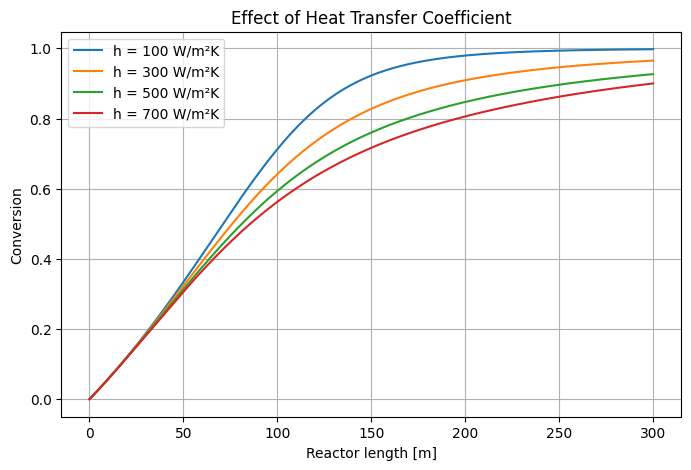

In [80]:
# Reset base case

reset_base_case()

hwall_list = [100, 300, 500, 700]

plt.figure(figsize=(8,5))

for h_case in hwall_list:

    hwall = h_case

    sol_case = solve_ivp(
        PFTR,
        [0, L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_case = (cEO0 - sol_case.y[0]) / cEO0

    plt.plot(
        sol_case.t,
        X_case,
        label=f'h = {h_case} W/m²K'
    )

plt.xlabel('Reactor length [m]')
plt.ylabel('Conversion')
plt.title('Effect of Heat Transfer Coefficient')
plt.legend()
plt.grid()
plt.show()

how can heat transfer coefficient be changed \
explain diagram

### 4.5 Reactor diameter

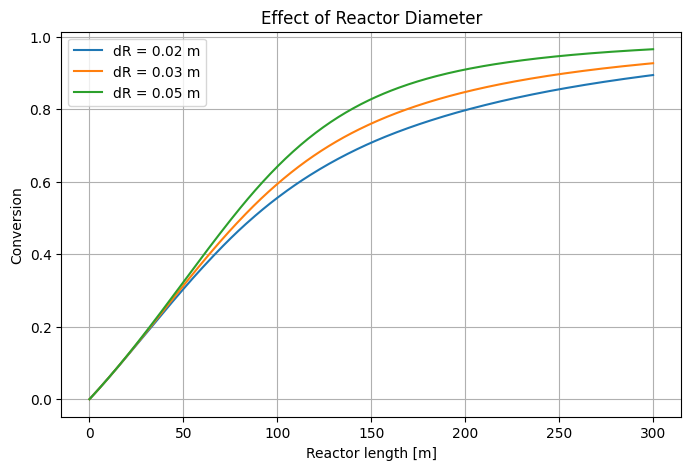

In [81]:
# Reset base case

reset_base_case()

dR_list = [0.02, 0.03, 0.05]  # m

plt.figure(figsize=(8,5))

for dR_i in dR_list:

    dR = dR_i

    #Geometric relations
    A_cross = np.pi*dR**2/4
    A_wall_per_length = np.pi*dR
    
    sol = solve_ivp(
        PFTR,
        [0, L],
        y0,
        method='BDF',
        t_eval=zeval
    )

    X_temp = (cEO0 - sol.y[0]) / cEO0

    plt.plot(zeval, X_temp, label=f"dR = {dR_i:.2f} m")

plt.xlabel("Reactor length [m]")
plt.ylabel("Conversion")
plt.title("Effect of Reactor Diameter")
plt.legend()
plt.grid()
plt.show()

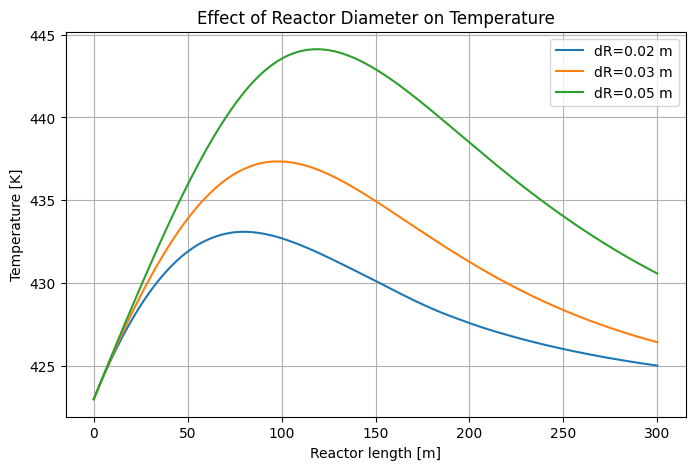

In [82]:
plt.figure(figsize=(8,5))

for dR_i in dR_list:

    dR = dR_i
    A_cross = np.pi*dR**2/4
    A_wall_per_length = np.pi*dR

    sol = solve_ivp(
        PFTR,
        [0,L],
        y0,
        method='BDF',
        t_eval=z
    )

    plt.plot(z, sol.y[2], label=f"dR={dR_i:.2f} m")

plt.xlabel("Reactor length [m]")
plt.ylabel("Temperature [K]")
plt.title("Effect of Reactor Diameter on Temperature")
plt.legend()
plt.grid()
plt.show()

## 5. Summary Table

In [83]:
print("Case Summary")
print("--------------------------")
print(f"Final Conversion = {X[-1]:.4f}")
print(f"Final Temperature = {T[-1]:.2f} K")
print(f"EO Outlet Concentration = {cEO[-1]:.2f} mol/m³")
print(f"EG Outlet Concentration = {cEG[-1]:.2f} mol/m³")

Case Summary
--------------------------
Final Conversion = 0.9265
Final Temperature = 426.44 K
EO Outlet Concentration = 166.91 mol/m³
EG Outlet Concentration = 2103.09 mol/m³


In [84]:
print("Tin =", Tin)
print("y0 =", y0)

y0 = [cEO0, cEG0, Tin]

print("nuevo y0 =", y0)

Tin = 423
y0 = [2270.    0.  423.]
nuevo y0 = [2270.0, 0.0, 423]
